p 0.0
p 0.1111111111111111
p 0.2222222222222222
p 0.3333333333333333
p 0.4444444444444444
p 0.5555555555555556
p 0.6666666666666666
p 0.7777777777777778
p 0.8888888888888888
p 1.0


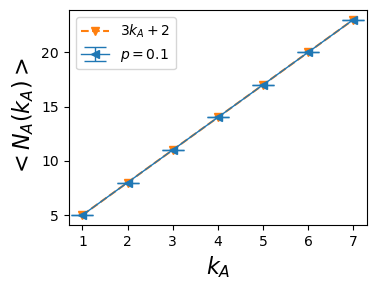

In [1]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import multi_dot
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix, lil_matrix
from scipy.sparse.linalg import inv, eigs
from scipy.linalg import svdvals
from scipy.stats import unitary_group
from scipy import linalg
from numpy import linalg as LA
import pylab
import time
import numba
from numba import njit,c16,i8,u2
import sys
import math

np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)

time_sta = time.time()

####################
#cilyinder geometry#
####################

#################################################
def create_transformation_pv_link(Ld,Lx,Ly):
#############################################
############ plaquette part #################
#############################################
    #p_indd = np.zeros((Lx*Ly,4),dtype='uint32')
    p_indd=[]
    for ip in range(Lx*(Ly)):
        ix,iy = ip%Lx,ip//Lx
        if iy==0:
            p_indd+=[[ix+(Ld-Lx)+Ld,ix+Ld,ix+Lx+Ld,((ix+1)%Lx)+Ld]] #please check(9/6)
            #print(ip,ix+(Ld-Lx),ix,ix+Lx,((ix+1)%Lx)) 
        elif iy==Ly-1:
            p_indd+=[[ix+(Lx)+(2*Lx)*(iy-1)+Ld,ix+(Lx)+(2*Lx)*(iy-1)+Lx+Ld,ix+(Ld-Lx)+Ld,(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx+Ld]] #please check (9/6)
            #print(ip,ix+(Lx)+(2*Lx)*(iy-1),ix+(Lx)+(2*Lx)*(iy-1)+Lx,ix+(Ld-Lx),(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx)
        else:
            p_indd+=[[ix+(Lx)+(2*Lx)*(iy-1)+Ld,ix+(Lx)+(2*Lx)*(iy-1)+Lx+Ld,ix+(Lx)+(2*Lx)*(iy-1)+(2*Lx)+Ld,(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx+Ld]]       
            #print(ip,ix+(Lx)+(2*Lx)*(iy-1),ix+(Lx)+(2*Lx)*(iy-1)+Lx,ix+(Lx)+(2*Lx)*(iy-1)+(2*Lx),(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx)
    #sys.exit()
###########  Here, we add Ld to an index to simplify determining a binary representation
###########  In other words, Ld corresponds to the shift in a binary representation
###########  since plaquette parts are pauli Z operator

############################################
############ vertex part ###################
############################################
    #v_indd = np.zeros(((Lx+1)*(Ly-1),4),dtype='uint32')
    v_indd =[]
    for iv in range((Lx)*(Ly-1)):
        ix,iy = iv%(Lx),iv//(Lx)
        if ix==0:
            v_indd+=[[iy*(2*Lx),(iy+1)*(2*Lx)-1,(iy+1)*(2*Lx),iy*(2*Lx)+Lx]]
            #print(iv,iy*(2*Lx),(iy+1)*(2*Lx)-1,(iy+1)*(2*Lx),iy*(2*Lx)+Lx)
        elif ix==Lx-1:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx]]
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx)
        else:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx]]
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx)
    ## iy=Ly-1 case
    for ix in range(Lx):
        iv=Lx*(Ly-1)+ix
        iy = Ly-1
        if ix==0:
            v_indd+=[[iy*(2*Lx),(iy+1)*(2*Lx)-1,ix,iy*(2*Lx)+Lx]] #please check(9/8)
            #print(iv,iy*(2*Lx),(iy+1)*(2*Lx)-1,ix,iy*(2*Lx)+Lx)
        elif ix==Lx-1:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx]] #please check(9/8)
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx)
        else:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx]] #please check(9/8)
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx)
    #sys.exit()
    return p_indd,v_indd

#################################################################
def initial_stabilizer_state(Ld,Lxd,Lyd,p_ind,v_ind):
    # Ld: total # of qubits
    MRi=np.zeros((Ld,2*Ld),dtype='uint32')
### star stabilizers  XXXX ###
    for iv in range((Lxd)*(Lyd)-1):
        #ivs=iv+(Lxd*(Lyd)-1)  # note that iv and ivs are different.
        MRi[iv][v_ind[iv]]=1 # neglect a phase factor
        #独立ではない最後のAvだけ取らない   
### plaquette stabilizers ZZZZ ###
    for ip in range(Lxd*Lyd-1):
        MRi[Lxd*(Lyd)-1+ip][p_ind[ip]]=1 # neglect a phase factor
        #独立ではない最後のBpだけ取らない
### Add logical operator prod X on upper rough boundary ###
    for kk in range(Lxd):
        MRi[Ld-2][kk]=1 #prod X (x-direction nonctractable)
        #print(kk,kk)
    for kk in range(Lyd):
        lo=Lxd+(2*Lxd)*kk
        MRi[Ld-1][lo]=1 #prod X (y-direction nonctractable)
        #print(kk,lo)
    #for kk in range(Ld):
    #    print(kk,MRi[kk,0:12],MRi[kk,12:24])
    #sys.exit()
    return MRi

## 9/9 dephasing update
def dephasing_dlinkXZ(dMR,ipd,dired,nsdd2,Ld,Lxd,Lyd,LOcheckd):
    #target dephasing links (please check 9/9)
    ix,iy = ipd%Lxd,ipd//Lxd
    if dired==0:
        if iy==0:
            diz=ix+(Ld-Lxd)
            dix=((ix+1)%Lxd)
        else:
            diz=ix+(Lxd)+(2*Lxd)*(iy-1)
            dix=(ix+1)%Lxd+(Lxd)+(2*Lxd)*(iy-1)+Lxd
    else:
        diz = ix+(Lxd)+(2*Lxd)*(iy-1)+Lxd
        dix = ix+(Lxd)+(2*Lxd)*(iy-1)+(2*Lxd)
    #print(888,ipd,dired,diz,dix)
    
    #di=di.astype('int64')
    MRXZ_bzbx=np.zeros((Ld),dtype='uint32')
    for kk in range(nsdd2):
        MRXZ_bzbx[kk]=dMR[kk,diz]+dMR[kk,dix+Ld] #(9/23,checked)
    MRXZ_bzbx=np.mod(MRXZ_bzbx,2)
    #################
    aid=np.where(MRXZ_bzbx[:]==1) # anticommute X search (9/9,please check)
    di_index_list=aid[0]
    lendi=len(di_index_list)
    # logical X string anticommute check
    if lendi !=0:
        if (di_index_list[0]==nsdd2-1) or (di_index_list[0]==nsdd2-2):
            #print(ipd,diz,dix)
            LOcheckd=1
            #print("logical X lost")

    if lendi !=0:
        k0=di_index_list[0]
        dMR_prev=dMR[k0,:].copy()
        #replace stabilizer for kc
        update_list=np.delete(di_index_list,0)
        dMR[update_list,:]=np.mod(dMR[update_list,:]+dMR_prev,2)
        dMR = np.delete(dMR,k0,0)
        nsdd2-=1
    #print("dephasingZZ2-a",(dMR2[:,di]+dMR2[:,(di+1)%Ld]))
    #print("------------------")
    return dMR,nsdd2,LOcheckd

### Negativity ###
def negativity_E(MRdn,nsdd2,Ld,Lxd,Lyd,sub_linkd):
    #A-subsystem negativity
    LA= len(sub_linkd) # total # of qubits in susbsystem A, [not determined(9/9)]
    # substitute the mixed state
    MRAB=MRdn
    mAB=nsdd2
    #for kk in range(2*Ld):
    #    print(999,kk,MRAB[1,kk])
    #print(mAB,LA)
    #sys.exit()
    #
    subA_link=sub_linkd #[0,1,2,3,4,5] #<==set link labels in A-subsystem
    #print(subA_link)
    #sys.exit()
    # Restriction A subsystem
    MRA=np.zeros((mAB,2*(LA)),dtype='uint32')
    for k2 in range(LA):
        MRA[:,k2]=MRAB[:,subA_link[k2]].copy()
        MRA[:,LA+k2]=MRAB[:,(Ld)+subA_link[k2]].copy()
    #for kk in range(LA):
    #    print(999,kk,subA_link[kk],MRA[7,kk],MRA[7,kk+LA])
    #print(mAB,LA)
    #sys.exit()
    #check matrix
    GcdA=np.zeros((2*LA,2*LA),dtype='uint32') # 2L * 2L matrix
    for k in range(LA):
        GcdA[k][LA+k]=1
        GcdA[LA+k][k]=1  
    # Create commutator matrix
    ComM=np.zeros((mAB,mAB),dtype='uint32')
    for i in range(mAB):
        for j in range(mAB):
        #check anti commtation
            gstabi=MRA[i,:]
            gstabj=MRA[j,:]
            acomgigj=np.dot(gstabi,np.dot(GcdA,gstabj.T))
            acomgigj=acomgigj%2  ## check: reduce Z2 value
            ComM[i,j]=acomgigj
    #rank of Commtator matrix
    rankJ=rank_mod2_v3(ComM)
    NA=0.5*rankJ
    return NA


#######################
def rank_mod2_v3(MRdd):
    # MRdA construct
    i = 0
    Ic = MRdd.shape[0]
    Jc = MRdd.shape[1]
    for j in range(Jc):
        check_ind=np.where(MRdd[i:,j]==1)
        if len(check_ind[0]) !=0:
            if len(check_ind[0]) >1:
                elim_ind=np.delete(check_ind,0)
                MRdd[elim_ind+i,:]=np.mod(MRdd[elim_ind+i,:]+MRdd[check_ind[0][0]+i,:],2)
            MRdd[i,:],MRdd[check_ind[0][0]+i,:] = MRdd[check_ind[0][0]+i,:],MRdd[i,:].copy()
            i=i+1
    return i

#################
### Main part ###
#################
Lx=16
Ly=6
#Ly=Lx
L=2*Lx*Ly # total # of link qubits
#Create plaquette and vertex lebels --> four or three surrouding link site labels
p_ind,v_ind = create_transformation_pv_link(L,Lx,Ly)
#check matrix
Gc=np.zeros((2*L,2*L),dtype='uint32') # 2L * 2L matrix
for k in range(L):
    Gc[k][L+k]=1
    Gc[L+k][k]=1  
Gc_csr=csr_matrix(Gc)
Nd = 200 # sample number
#print(ip)
p_list=[]
Np=10
Nk=7
NA_total_list=np.zeros((Nk,Nd),dtype='uint32')
for ip in range(Np):
    # stabilizer matrix
    MR=np.zeros((L,2*L),dtype='uint32') # L * 2L matrix
    R2_list=[]
    pdp=ip/(Np-1)
    print("p",pdp)
    p_list=np.append(p_list,pdp)
    for ids in range(Nd):
        #print(pdp,ids)
        MR=initial_stabilizer_state(L,Lx,Ly,p_ind,v_ind) #
        nsd2=L
        #pdp=1
        # One-layer dephasing circuit
        #stochestic dephasing for each XZ diagonal link
        LO_label=0
        for ip in range(Lx*Ly):
            # dephasing p+lower diagonal link
            todo=[0,1]
            prob_list = [pdp,1-pdp]
            pout = np.random.choice(todo,size=None,replace=True, p=prob_list)
            if pout == 0:
                if nsd2 !=0:
                    dire=1
                    MR,nsd2,LO_label=dephasing_dlinkXZ(MR,ip,dire,nsd2,L,Lx,Ly,LO_label)
        for ip in range(Lx*Ly):
            # dephasing p+upper diagonal link
            todo=[0,1]
            prob_list = [pdp,1-pdp]
            pout = np.random.choice(todo,size=None,replace=True, p=prob_list)
            if pout == 0:
                if nsd2 !=0:
                    dire=0
                    MR,nsd2,LO_label=dephasing_dlinkXZ(MR,ip,dire,nsd2,L,Lx,Ly,LO_label)
        # different sub-system negativity
        #NA_even_list=[]
        #kA_list=[]
        for ki in range(Nk):
            ## create sub_linkA ##
            link_sum = np.zeros(L,dtype='uint32')
            kA=ki+1
            llA=2*kA
            #kA_list=np.append(kA_list,kA)
            for ix in range(llA):
                for iy in range(2):
                    link_pd = np.zeros(L,dtype='uint32')
                    ip = ix + (iy)*Lx
                    p_indd=[x-L for x in p_ind[ip]]
                    link_pd[p_indd]=1
                    link_sum = link_sum + link_pd
            sub_At=np.nonzero(link_sum)
            sub_A=sub_At[0]
            NegadA=negativity_E(MR,nsd2,L,Lx,Ly,sub_A)
            NA_total_list[ki,ids]=NegadA
    #################
    NA_kA_ave_list=[]
    NA_kA_error_list=[]
    for ki in range(Nk):
        Nkdis=NA_total_list[ki,:]
        NA_kA_ave=np.mean(Nkdis)
        NA_kA_error_d=np.std(Nkdis, ddof=1)/ np.sqrt(len(Nkdis))
        NA_kA_ave_list=np.append(NA_kA_ave_list,NA_kA_ave)
        NA_kA_error_list=np.append(NA_kA_error_list,NA_kA_error_d)
        kAd=ki+1
        with open("p="+str(pdp)+"Lx="+str(Lx)+"Ly="+str(Ly)+"_NA.lst", 'a') as f:
            f.writelines(str(pdp)+'\t'+str(kAd)+'\t'+str(NA_kA_ave)+'\t'+str(NA_kA_error_d)+"\n")
kA_list=[1,2,3,4,5,6,7]
maximal_NA=[5,8,11,14,17,20,23]
fig, ax = plt.subplots(figsize=(4,3))
ax.set_xlabel(r'$k_A$',fontsize=16)  # x軸ラベル
#ax.set_xlabel('$$')  # x軸ラベル
ax.set_ylabel(r'$<N_A(k_A)>$',fontsize=16)  # y軸ラベル
#ax.set_xscale('log')
#ax.set_yscale('log')
#ax.tick_params(labelsize=14,colors = "blue")
#ax.set_title('Energy') # グラフタイトル
# ax.set_aspect('equal') # スケールを揃える
#ax.grid()            # 罫線
#ax.set_xlim([0.5, 1]) # x方向の描画範囲を指定
#ax.set_ylim([20,50])    # y方向の描画範囲を指定
#ax.plot(m_list1,SGO,'o',label=r'SGO')
#ax.plot(p_list1,chie1,'o',label=r'L=32')
#ax.plot(p_list2,chie2,'^',label=r'L=48')
ax.errorbar(kA_list,NA_kA_ave_list,yerr=NA_kA_error_list, marker='<', capthick=1, capsize=8, lw=1,label=r'$p=0.1$')
ax.plot(kA_list,maximal_NA,'v',linestyle='dashed',label=r'$3k_A+2$')
#ax.errorbar(p_list2,chi2*48,yerr=chie2, marker='<', capthick=1, capsize=8, lw=1,label=r'$L=48$')
#ax.axhline(y=0.855, xmin=0, xmax=100, color='r',linestyle='dashed')
#ax.axhline(y=0.76502613805585, xmin=0, xmax=100, color='r',linestyle='dashed')
ax.legend(loc=0)    # 凡例
#ax.legend(loc='upper left', bbox_to_anchor=(1,1))    # 凡例
fig.tight_layout()  # レイアウトの設定
#plt.savefig('CoM_L=512.svg') # 画像の保存
plt.show()

In [2]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import multi_dot
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix, lil_matrix
from scipy.sparse.linalg import inv, eigs
from scipy.linalg import svdvals
from scipy.stats import unitary_group
from scipy import linalg
from numpy import linalg as LA
import pylab
import time
import numba
from numba import njit,c16,i8,u2
import sys
import math

np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)

time_sta = time.time()

####################
#cilyinder geometry#
####################

#################################################
def create_transformation_pv_link(Ld,Lx,Ly):
#############################################
############ plaquette part #################
#############################################
    #p_indd = np.zeros((Lx*Ly,4),dtype='uint32')
    p_indd=[]
    for ip in range(Lx*(Ly)):
        ix,iy = ip%Lx,ip//Lx
        if iy==0:
            p_indd+=[[ix+(Ld-Lx)+Ld,ix+Ld,ix+Lx+Ld,((ix+1)%Lx)+Ld]] #please check(9/6)
            #print(ip,ix+(Ld-Lx),ix,ix+Lx,((ix+1)%Lx)) 
        elif iy==Ly-1:
            p_indd+=[[ix+(Lx)+(2*Lx)*(iy-1)+Ld,ix+(Lx)+(2*Lx)*(iy-1)+Lx+Ld,ix+(Ld-Lx)+Ld,(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx+Ld]] #please check (9/6)
            #print(ip,ix+(Lx)+(2*Lx)*(iy-1),ix+(Lx)+(2*Lx)*(iy-1)+Lx,ix+(Ld-Lx),(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx)
        else:
            p_indd+=[[ix+(Lx)+(2*Lx)*(iy-1)+Ld,ix+(Lx)+(2*Lx)*(iy-1)+Lx+Ld,ix+(Lx)+(2*Lx)*(iy-1)+(2*Lx)+Ld,(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx+Ld]]       
            #print(ip,ix+(Lx)+(2*Lx)*(iy-1),ix+(Lx)+(2*Lx)*(iy-1)+Lx,ix+(Lx)+(2*Lx)*(iy-1)+(2*Lx),(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx)
    #sys.exit()
###########  Here, we add Ld to an index to simplify determining a binary representation
###########  In other words, Ld corresponds to the shift in a binary representation
###########  since plaquette parts are pauli Z operator

############################################
############ vertex part ###################
############################################
    #v_indd = np.zeros(((Lx+1)*(Ly-1),4),dtype='uint32')
    v_indd =[]
    for iv in range((Lx)*(Ly-1)):
        ix,iy = iv%(Lx),iv//(Lx)
        if ix==0:
            v_indd+=[[iy*(2*Lx),(iy+1)*(2*Lx)-1,(iy+1)*(2*Lx),iy*(2*Lx)+Lx]]
            #print(iv,iy*(2*Lx),(iy+1)*(2*Lx)-1,(iy+1)*(2*Lx),iy*(2*Lx)+Lx)
        elif ix==Lx-1:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx]]
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx)
        else:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx]]
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx)
    ## iy=Ly-1 case
    for ix in range(Lx):
        iv=Lx*(Ly-1)+ix
        iy = Ly-1
        if ix==0:
            v_indd+=[[iy*(2*Lx),(iy+1)*(2*Lx)-1,ix,iy*(2*Lx)+Lx]] #please check(9/8)
            #print(iv,iy*(2*Lx),(iy+1)*(2*Lx)-1,ix,iy*(2*Lx)+Lx)
        elif ix==Lx-1:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx]] #please check(9/8)
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx)
        else:
            v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx]] #please check(9/8)
            #print(iv,ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix,ix+iy*(2*Lx)+Lx)
    #sys.exit()
    return p_indd,v_indd
